In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                              ConfusionMatrixDisplay, accuracy_score)
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/features.csv', parse_dates=['date'])

FEATURES = [
    'home_form_win_rate', 'home_form_goals_scored', 'home_form_goals_conceded',
    'away_form_win_rate', 'away_form_goals_scored', 'away_form_goals_conceded',
    'h2h_home_wins', 'h2h_draws', 'h2h_away_wins',
    'tournament_weight', 'is_neutral', 'form_diff', 'goals_diff',
]

TARGET = 'outcome'

print(f"Dataset: {df.shape}")
print(f"Class distribution:\n{df[TARGET].value_counts()}")

Dataset: (50576, 20)
Class distribution:
outcome
H    24935
A    14185
D    11456
Name: count, dtype: int64


In [3]:
# Use everything before 2018 for training, 2018+ for testing
# This simulates real-world deployment honestly
split_date = '2018-01-01'

train = df[df['date'] < split_date]
test  = df[df['date'] >= split_date]

X_train = train[FEATURES]
y_train = train[TARGET]

X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f"Training set: {len(X_train)} matches (up to 2018)")
print(f"Test set:     {len(X_test)} matches (2018 onwards)")
print(f"\nTrain class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")

Training set: 42524 matches (up to 2018)
Test set:     8052 matches (2018 onwards)

Train class balance:
outcome
H    0.497
A    0.279
D    0.224
Name: proportion, dtype: float64

Test class balance:
outcome
H    0.472
A    0.290
D    0.238
Name: proportion, dtype: float64


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  
# Note: transform only on test — never fit_transform
# Fitting on test would leak test distribution into scaling

In [6]:
lr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    C=1.0  # regularisation strength — we'll tune this later
)

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")
print()
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
Accuracy: 0.535

              precision    recall  f1-score   support

           A       0.53      0.39      0.45      2336
           D       0.20      0.00      0.00      1916
           H       0.54      0.89      0.67      3800

    accuracy                           0.53      8052
   macro avg       0.42      0.43      0.37      8052
weighted avg       0.46      0.53      0.45      8052



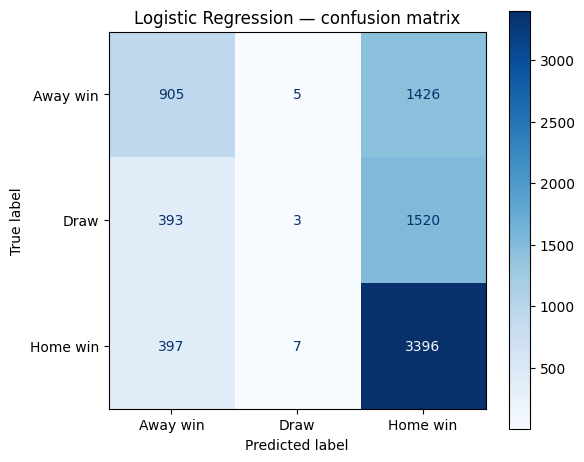

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, 
    display_labels=['Away win', 'Draw', 'Home win'],
    cmap='Blues', ax=ax
)
ax.set_title('Logistic Regression — confusion matrix')
plt.tight_layout()
plt.savefig('../data/processed/cm_logistic.png', dpi=150)
plt.show()

In [8]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)  
y_pred_rf = rf.predict(X_test_scaled)

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print()
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.537

              precision    recall  f1-score   support

           A       0.55      0.38      0.44      2336
           D       0.00      0.00      0.00      1916
           H       0.53      0.91      0.67      3800

    accuracy                           0.54      8052
   macro avg       0.36      0.43      0.37      8052
weighted avg       0.41      0.54      0.45      8052



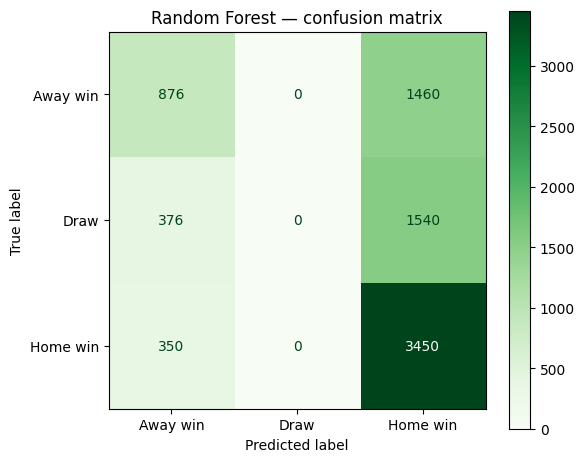

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Away win', 'Draw', 'Home win'],
    cmap='Greens', ax=ax
)
ax.set_title('Random Forest — confusion matrix')
plt.tight_layout()
plt.savefig('../data/processed/cm_randomforest.png', dpi=150)
plt.show()

In [10]:
X_all = df[FEATURES]
y_all = df[TARGET]
X_all_scaled = scaler.fit_transform(X_all)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_scores = cross_val_score(lr, X_all_scaled, y_all, cv=cv, scoring='accuracy')
rf_scores = cross_val_score(rf, X_all_scaled, y_all, cv=cv, scoring='accuracy')

print("5-fold cross-validation accuracy:")
print(f"  Logistic Regression: {lr_scores.mean():.3f} ± {lr_scores.std():.3f}")
print(f"  Random Forest:       {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")

5-fold cross-validation accuracy:
  Logistic Regression: 0.546 ± 0.001
  Random Forest:       0.551 ± 0.003


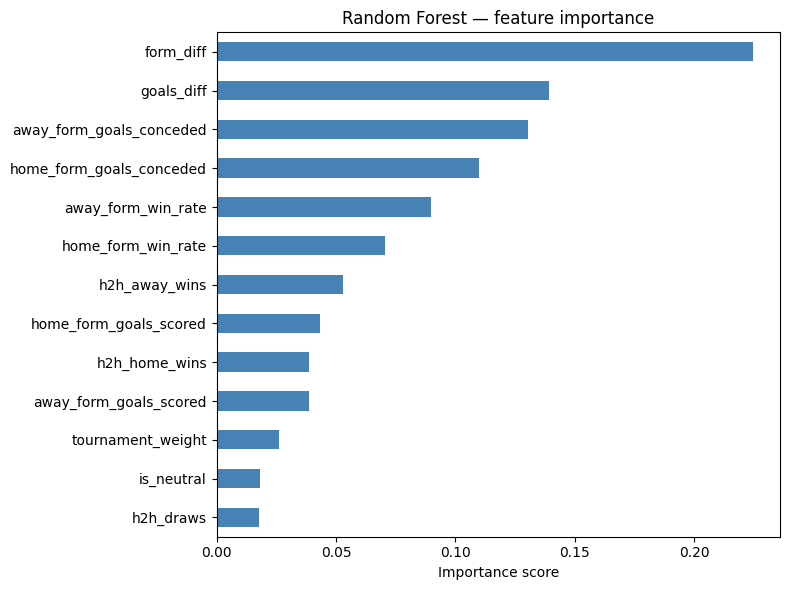


Top 5 most important features:
form_diff                   0.224672
goals_diff                  0.139231
away_form_goals_conceded    0.130551
home_form_goals_conceded    0.109917
away_form_win_rate          0.089642
dtype: float64


In [11]:
importances = pd.Series(rf.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Random Forest — feature importance')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=150)
plt.show()

print("\nTop 5 most important features:")
print(importances.sort_values(ascending=False).head())

In [12]:
# Baseline: what if we just predicted "Home win" every time?
naive_accuracy = (y_test == 'H').mean()
print(f"Naive baseline (always predict home win): {naive_accuracy:.3f}")
print(f"Logistic Regression:                      {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"Random Forest:                            {accuracy_score(y_test, y_pred_rf):.3f}")

# How much better than random are we?
random_baseline = 1/3
print(f"\nRandom baseline (3 classes):              {random_baseline:.3f}")

Naive baseline (always predict home win): 0.472
Logistic Regression:                      0.535
Random Forest:                            0.537

Random baseline (3 classes):              0.333


In [13]:
import joblib
import os

os.makedirs('../src', exist_ok=True)

# Choose your best model — likely Random Forest
joblib.dump(rf, '../src/model.pkl')
joblib.dump(scaler, '../src/scaler.pkl')

# Save feature list so the app uses the exact same order
import json
with open('../src/features.json', 'w') as f:
    json.dump(FEATURES, f)

# Save the full team list for the Streamlit dropdowns
all_teams = sorted(pd.concat([df['home_team'], df['away_team']]).unique().tolist())
with open('../src/teams.json', 'w') as f:
    json.dump(all_teams, f)

print("Saved:")
print("  src/model.pkl")
print("  src/scaler.pkl")
print("  src/features.json")
print("  src/teams.json")
print(f"\nTeams available: {len(all_teams)}")

Saved:
  src/model.pkl
  src/scaler.pkl
  src/features.json
  src/teams.json

Teams available: 333
